In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.71 s (started: 2026-07-02 22:12:48 +02:00)


In [2]:
scarf.fetch_dataset(dataset_name="tenx_10K_pbmc-v1_atacseq", save_path="scarf_datasets")

time: 28.5 s (started: 2026-07-02 22:12:50 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5")
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


time: 58.5 ms (started: 2026-07-02 22:13:18 +02:00)


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr",
    chunk_size=(1000, 2000),
)
writer.dump(batch_size=1000)

ValueError: Codec does not support buffers of > 2147483647 bytes

time: 14.7 s (started: 2026-07-02 22:13:18 +02:00)


In [5]:
ds = scarf.DataStore("scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr", nthreads=4)

More than of half of the less have less than 10 features for assay: ATAC. Will not remove low quality cells automatically.



time: 4.24 s (started: 2026-07-02 22:13:32 +02:00)


8728 cells flagged for filtering out using attribute ATAC_nCounts



8728 cells flagged for filtering out using attribute ATAC_nFeatures



/home/parashar/scarf/.venv/lib/python3.14/site-packages/scipy/stats/_distn_infrastructure.py:2337: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/parashar/scarf/.venv/lib/python3.14/site-packages/scipy/stats/_distn_infrastructure.py:2338: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


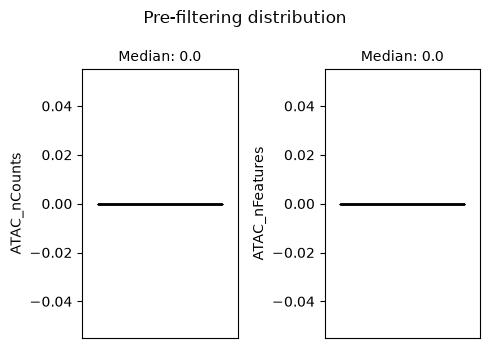

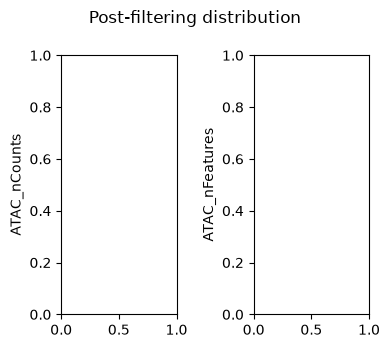

time: 1.35 s (started: 2026-07-02 22:13:36 +02:00)


In [6]:
ds.auto_filter_cells()

In [7]:
ds.mark_prevalent_peaks(top_n=25000)

IndexError: tuple index out of range

time: 295 ms (started: 2026-07-02 22:13:38 +02:00)


In [8]:
ds.ATAC.feats.head()

,I,ids,names,nCells,dropOuts
0,False,chr1:565107-565550,chr1:565107-565550,0,8728
1,False,chr1:569174-569639,chr1:569174-569639,0,8728
2,False,chr1:713460-714823,chr1:713460-714823,0,8728
3,False,chr1:752422-753038,chr1:752422-753038,0,8728
4,False,chr1:762106-763359,chr1:762106-763359,0,8728


time: 90.6 ms (started: 2026-07-02 22:13:38 +02:00)


In [9]:
ds.make_graph(
    feat_key="prevalent_peaks",
    k=21,
    dims=50,
    n_centroids=100,
    lsi_skip_first=True,
)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.0s (computing)



ValueError: ERROR: Either I__prevalent_peaks does not exist or is not bool type

time: 256 ms (started: 2026-07-02 22:13:38 +02:00)


In [10]:
ds.run_umap(n_epochs=500, min_dist=0.1, spread=1, parallel=True)

KeyError: 'latest_feat_key'

time: 110 ms (started: 2026-07-02 22:13:38 +02:00)


In [11]:
ds.run_leiden_clustering(resolution=0.6)

KeyError: 'latest_feat_key'

time: 269 ms (started: 2026-07-02 22:13:39 +02:00)


In [12]:
ds.cells.head()

,I,ids,names,ATAC_nFeatures,ATAC_nCounts
0,False,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,0.0,0.0
1,False,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,0.0,0.0
2,False,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,0.0,0.0
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,0.0,0.0
4,False,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,0.0,0.0


time: 75.1 ms (started: 2026-07-02 22:13:39 +02:00)


In [13]:
ds.plot_layout(layout_key="ATAC_UMAP", color_by="ATAC_leiden_cluster")

KeyError: 'ATAC_UMAP1 does not exist in the metadata columns.'

time: 146 ms (started: 2026-07-02 22:13:39 +02:00)


In [14]:
scarf.fetch_dataset(dataset_name="annotations", save_path="scarf_datasets")

time: 8.91 s (started: 2026-07-02 22:13:39 +02:00)


In [15]:
ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn="scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz",
    peaks_col="ids",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)

33898/62409 features did not overlap with any peak



/home/parashar/scarf/scarf/meld_assay.py:425: RuntimeWarning: invalid value encountered in divide
  tf = a / n_term_per_doc[s : s + a.shape[0]].reshape(-1, 1)


/home/parashar/scarf/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/parashar/scarf/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Minimum cell count (0.0) is lower than size factor multiplier (1000)



Percentage feature GeneScores_percentMito not added because not detected in any cell



Percentage feature GeneScores_percentRibo not added because not detected in any cell



time: 36.1 s (started: 2026-07-02 22:13:48 +02:00)


In [16]:
ds

DataStore has 0 (8728) cells with 2 assays: GeneScores ATAC
   Cell metadata:
            'I', 'ids', 'names', 'GeneScores_nCounts', 'ATAC_nCounts', 
            'GeneScores_nFeatures', 'ATAC_nFeatures'
   ATAC assay has 0 (89796) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          
   GeneScores assay has 0 (62409) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 91.6 ms (started: 2026-07-02 22:14:23 +02:00)


In [17]:
ds.plot_layout(
    layout_key="ATAC_UMAP",
    from_assay="GeneScores",
    color_by=["CD3D", "MS4A1", "LEF1", "NKG7", "TREM1", "LYZ"],
    clip_fraction=0.01,
    n_columns=3,
    width=3,
    height=3,
    point_size=5,
    scatter_kwargs={"lw": 0.01},
)

KeyError: 'ATAC_UMAP1 does not exist in the metadata columns.'

time: 211 ms (started: 2026-07-02 22:14:24 +02:00)
